In [45]:
import numpy as np
import matplotlib.pyplot as plt
import maglab
import torch
import pandas as pd
import os
from scipy.ndimage import gaussian_filter, map_coordinates
from pyevtk.hl import gridToVTK

In [46]:
l = 0
# file_path = f'D:\\Projects\\TargetSkyrmion\\targetdata\\3dmi_loss\\{l:g}_layers_loss\\results\\loss{l:.1e}_wphi1.0e+07'
file_path = f'D:\\Projects\\TargetSkyrmion\\targetdata\\1test_phi\\results\\loss{l:.1e}_wphi1.0e+07'

In [ ]:
def segment_spin_data(spin_tensor: torch.Tensor, smoothing_sigma: float = 2.0):
    if not isinstance(spin_tensor, torch.Tensor):
        raise TypeError("The input data must be PyTorch tensor!")

    if spin_tensor.dim() != 4 or spin_tensor.shape[0] != 3:
        raise ValueError(f"The tensor's shape must be (3, nx, ny, nz), but received {spin_tensor.shape}")

    spin = spin_tensor.cpu().numpy()
    _, nx, ny, nz = spin.shape
    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
    print(f"data parameter: nx={nx}, ny={ny}, nz={nz}")
    
    num_angles = 360
    max_radius = int(min(cx, cy)) + 1
    midpoint_radii = np.full((nz, num_angles), np.nan)

    for k in range(nz):
        mz_slice = spin[2, :, :, k]
        for i in range(num_angles):
            angle = 2 * np.pi * i / num_angles
            cos_a, sin_a = np.cos(angle), np.sin(angle)        
            zero_crossings_r = []
            mz_prev = mz_slice[int(round(cx)), int(round(cy))] 
            for r in range(1, max_radius):
                x_pos, y_pos = cx + r * cos_a, cy + r * sin_a
                if not (0 <= x_pos < nx and 0 <= y_pos < ny):
                    break
                
                ix, iy = int(round(x_pos)), int(round(y_pos))
                mz_current = mz_slice[ix, iy]
                
                if np.sign(mz_current) != np.sign(mz_prev):
                    zero_crossings_r.append(r)
                    if len(zero_crossings_r) == 2:
                        break
                mz_prev = mz_current

            if len(zero_crossings_r) >= 2:
                midpoint_radii[k, i] = (zero_crossings_r[0] + zero_crossings_r[1]) / 2.0
            elif k > 0:
                midpoint_radii[k, i] = midpoint_radii[k-1, i]

    if np.isnan(midpoint_radii[0, :]).any():
        mean_radius_z0 = np.nanmean(midpoint_radii[0, :])
        midpoint_radii[0, np.isnan(midpoint_radii[0, :])] = mean_radius_z0

    for k in range(1, nz):
        if np.isnan(midpoint_radii[k, :]).any():
            nan_indices = np.isnan(midpoint_radii[k, :])
            midpoint_radii[k, nan_indices] = midpoint_radii[k-1, nan_indices]

    if smoothing_sigma > 0:
        smooth_midpoint_radii = gaussian_filter(midpoint_radii, sigma=smoothing_sigma, mode='wrap')
    else:
        smooth_midpoint_radii = midpoint_radii 
    
    spin_skyrmion_np = np.zeros_like(spin)
    spin_edge_np = np.zeros_like(spin)

    ii, jj = np.mgrid[0:nx, 0:ny]
    distance_from_center = np.sqrt((ii - cx)**2 + (jj - cy)**2)
    angle_from_center = np.arctan2(jj - cy, ii - cx)
    angle_indices = np.round((angle_from_center + np.pi) / (2 * np.pi) * (num_angles - 1)).astype(int)
    angle_indices = np.clip(angle_indices, 0, num_angles-1) 

    for k in range(nz):
        boundary_radii_slice = smooth_midpoint_radii[k, angle_indices]
        inner_mask_2d = distance_from_center < boundary_radii_slice

        spin_slice_k = spin[:, :, :, k]
        
        spin_skyrmion_np[:, :, :, k] = np.where(inner_mask_2d, spin_slice_k, 0)
        spin_edge_np[:, :, :, k] = np.where(~inner_mask_2d, spin_slice_k, 0)

    spin_skyrmion_tensor = torch.from_numpy(spin_skyrmion_np).to(spin_tensor.dtype).to(spin_tensor.device)
    spin_edge_tensor = torch.from_numpy(spin_edge_np).to(spin_tensor.dtype).to(spin_tensor.device)
    return spin_skyrmion_tensor, spin_edge_tensor

def get_spin(file_path="path_file"):
    file_path = file_path
    dx = 1.06e-9
    geo = maglab.geo.cylider(136, 111)
    nx, ny, nz = geo.shape
    micro = maglab.Micro(nx, ny, nz, dx)
    state = micro.load_state(f"{file_path}/final.pth")
    spin = state.spin
    spin_skyrmion, spin_edge = segment_spin_data(spin.detach().cpu())
    return spin, spin_skyrmion, spin_edge, nz

def create_skyrmion_mask_and_vtk(spin_tensor: torch.Tensor, 
                                 target_mz: float = 0.0, 
                                 smoothing_sigma: float = 2.0,
                                 R_conf: float = None, 
                                 output_filename: str = None):
    """
    According to the target_mz isovalue surface, segment a 3D spin data tensor, and before generating Mask and VTK,
    rotate the obtained distance field (distance_field_np) by 180 degrees in the XY plane center.

    R_conf: limit the calculation radius for each ray.
    target_mz: the mz isovalue for segmentation.
    """
    if not isinstance(spin_tensor, torch.Tensor):
        raise TypeError("The input data must be PyTorch tensor!")

    if spin_tensor.dim() != 4 or spin_tensor.shape[0] != 3:
        raise ValueError(f"The tensor's shape must be (3, nx, ny, nz), but received {spin_tensor.shape}")
    
    spin = spin_tensor.cpu().numpy()
    _, nx, ny, nz = spin.shape
    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0

    if R_conf is None:
        R_conf = min(cx, cy) 
    
    num_angles = 720
    boundary_radii = np.full((nz, num_angles), np.nan)

    def find_boundary_radius_for_slice(k):
        mz_slice = spin[2, :, :, k]
        radii_k = np.full(num_angles, np.nan)

        max_r_step = int(np.ceil(R_conf))   # the maximum number of steps along the ray
        
        for i in range(num_angles):
            angle = 2 * np.pi * i / num_angles
            cos_a, sin_a = np.cos(angle), np.sin(angle)
            
            zero_crossings_r = []
            mz_prev = mz_slice[int(round(cx)), int(round(cy))]

            for r in range(1, max_r_step + 1): 
                x_pos, y_pos = cx + r * cos_a, cy + r * sin_a

                ix, iy = int(round(x_pos)), int(round(y_pos))
                if not (0 <= ix < nx and 0 <= iy < ny):
                    break
                
                mz_current = mz_slice[ix, iy]

                if np.sign(mz_current - target_mz) != np.sign(mz_prev - target_mz):
                    if (mz_current - mz_prev) != 0: 
                        r_exact = r - 1 + abs(target_mz - mz_prev) / abs(mz_current - mz_prev)
                        if r_exact <= R_conf:
                            zero_crossings_r.append(r_exact)
                            if len(zero_crossings_r) == 2:
                                break
                mz_prev = mz_current

            if len(zero_crossings_r) >= 2:
                radii_k[i] = (zero_crossings_r[0] + zero_crossings_r[1]) / 2.0
        
        return radii_k

    def fill_intra_slice_nans(radii_arr):
        nan_indices = np.isnan(radii_arr)
        if np.any(nan_indices):
            if np.all(nan_indices):
                radii_arr[:] = 0.0
            else:
                mean_val = np.nanmean(radii_arr)
                radii_arr[nan_indices] = mean_val
        return radii_arr

    mid_z = nz // 2 # from middle slice to both ends
    print(f"Processing center slice: {mid_z}")
    center_radii = find_boundary_radius_for_slice(mid_z)
    boundary_radii[mid_z, :] = fill_intra_slice_nans(center_radii)

    # (mid_z + 1 -> nz - 1)
    for k in range(mid_z + 1, nz):
        current_radii = find_boundary_radius_for_slice(k)
        prev_radii = boundary_radii[k-1, :]
        boundary_radii[k, :] = np.where(np.isnan(current_radii), prev_radii, current_radii)

    # (mid_z - 1 -> 0)
    for k in range(mid_z - 1, -1, -1):
        current_radii = find_boundary_radius_for_slice(k)
        prev_radii = boundary_radii[k+1, :]
        boundary_radii[k, :] = np.where(np.isnan(current_radii), prev_radii, current_radii)

    if smoothing_sigma > 0:
        smooth_boundary_radii = gaussian_filter(boundary_radii, sigma=smoothing_sigma, mode='nearest')
    else:
        smooth_boundary_radii = boundary_radii

    ii, jj = np.mgrid[0:nx, 0:ny]
    distance_from_center = np.sqrt((ii - cx)**2 + (jj - cy)**2)
    angle_from_center = np.arctan2(jj - cy, ii - cx)
    
    angle_indices = np.round((angle_from_center + np.pi) / (2 * np.pi) * (num_angles - 1)).astype(int)
    angle_indices = np.clip(angle_indices, 0, num_angles - 1)

    distance_field_np = np.zeros((nx, ny, nz), dtype=np.float32)

    for k in range(nz):
        boundary_radii_slice = smooth_boundary_radii[k, angle_indices]
        distance_field_np[:, :, k] = distance_from_center - boundary_radii_slice
    
    distance_field_np = gaussian_filter(distance_field_np, sigma=1.5)
    
    # rotate the distance field by 180 degrees around Z axis
    rotated_distance_field_np = np.rot90(distance_field_np, k=2, axes=(0, 1))
    inner_mask_3d = rotated_distance_field_np < 0.0

    # output VTK file if filename is provided
    if output_filename:
            grid_spacing = 1.06e-9 
            origin_x = -(nx - 1) / 2.0 * grid_spacing
            origin_y = -(ny - 1) / 2.0 * grid_spacing
            origin_z = -(nz - 1) / 2.0 * grid_spacing

            x = np.linspace(origin_x, origin_x + (nx-1)*grid_spacing, nx)
            y = np.linspace(origin_y, origin_y + (ny-1)*grid_spacing, ny)
            z = np.linspace(origin_z, origin_z + (nz-1)*grid_spacing, nz)

            rotated_distance_field_fortran = np.asfortranarray(rotated_distance_field_np)
            gridToVTK(output_filename, x, y, z, pointData={'distance_field': rotated_distance_field_fortran})        
    return inner_mask_3d

def skyrmion_number_2d(spin):
    """
    2D topological charge calculation for a spin configuration.
    Args:
        spin (torch.Tensor): input a 2D spin tensor; shape should be (3, nx, ny).   
    Returns:
        torch.Tensor: a 0D tensor; has included Q that had been calculated.
    """

    if spin.dim() != 3 or spin.shape[0] != 3:
        raise ValueError(f"The tensor's shape must be (3, nx, ny), but received {spin.shape}")

    dm_dx = torch.gradient(spin, dim=1)[0]
    dm_dy = torch.gradient(spin, dim=2)[0]
    cross_product = torch.cross(dm_dx, dm_dy, dim=0)   
    integrand = torch.sum(spin * cross_product, dim=0)

    return torch.sum(integrand) / (4 * torch.pi)

def plt_fig(x, y):
    plt.figure(figsize=(8, 5))  
    plt.plot(np.arange(x)*1.06, y, marker='o', linestyle='-') 
    plt.xlabel("z (nm)")
    plt.ylabel("Topological Charge Q")
    plt.show()

def save_dat(file_name='filename.dat', *args):
    if len(args) % 2 != 0:
        raise ValueError("Arguments must be provided in pairs of 'column_name' and data.")

    data_dict = {}
    for i in range(0, len(args), 2):
        column_name = args[i]
        data = args[i+1]
        if not isinstance(column_name, str):
            raise TypeError(f"Expected a string for a column name, but got {type(column_name)}.")
        data_dict[column_name] = data
          
    output_df = pd.DataFrame(data_dict)
    output_df.to_csv(file_name, sep='\t', index=False, float_format='%.8f')

Calculate partial and total Q (interior skyrmion, edge twist and total)

data parameter: nx=136, ny=136, nz=111
Processing center slice: 55


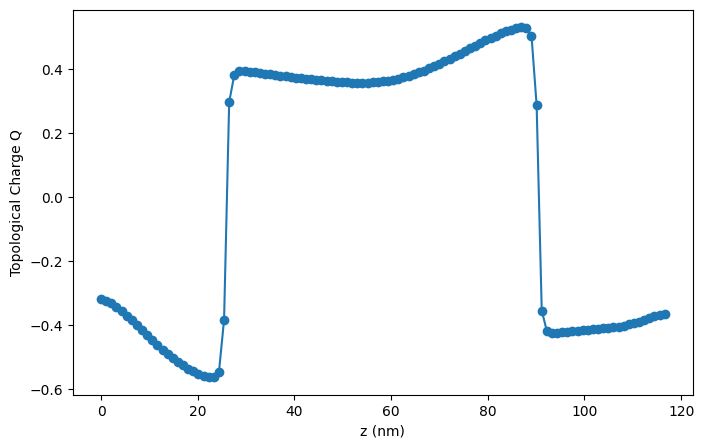

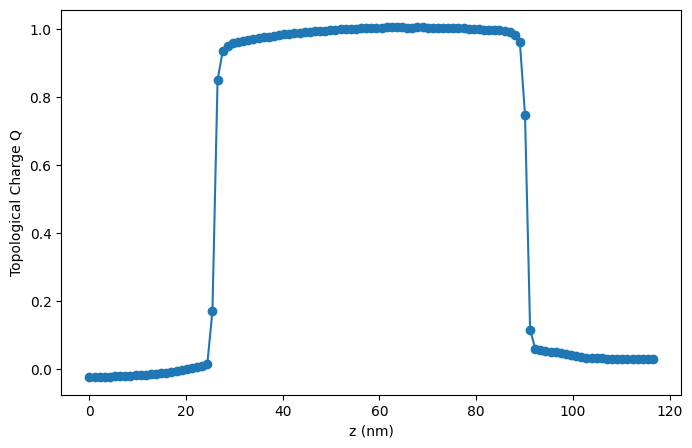

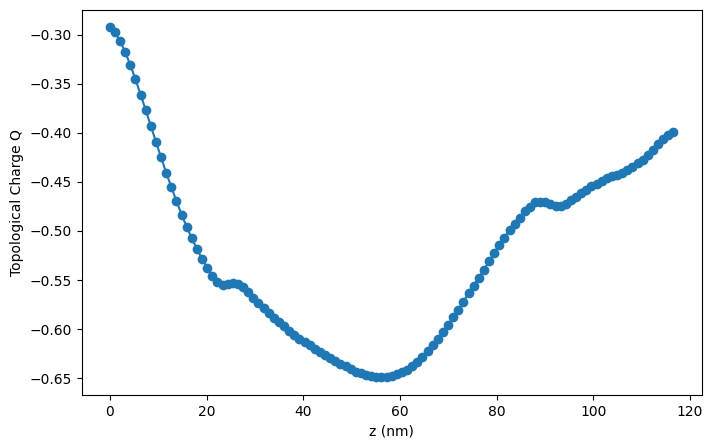

In [48]:
spin, spin_skyrmion, spin_edge, nz = get_spin(file_path)

inner_mask_np = create_skyrmion_mask_and_vtk(
    spin_tensor=spin.detach().cpu(),
    target_mz=-0.9,
    smoothing_sigma=2.0,
    R_conf=50,
    output_filename=f'{file_path}/{l:g}mask'
)
inner_mask_tensor = torch.from_numpy(inner_mask_np).to(spin.device)
spin_skyrmion = spin * inner_mask_tensor  
spin_edge = spin * (~inner_mask_tensor)

z, Q_skyrmion_layers, Q_edge_layers = [], [], []
for i in range(nz):
    z.append(i*1.06)
    spin_skyrmion_layer = spin_skyrmion[:, :, :, i]
    Q_skyrmion = skyrmion_number_2d(spin_skyrmion_layer)
    Q_skyrmion_layers.append(Q_skyrmion.item())

    spin_edge_layer = spin_edge[:, :, :, i]
    Q_edge = skyrmion_number_2d(spin_edge_layer)
    Q_edge_layers.append(Q_edge.item())

z, Q_all_layers = [], []
for i in range(nz):
    z.append(i*1.06)
    spin_layer = spin[:, :, :, i]
    Q = skyrmion_number_2d(spin_layer)
    Q_all_layers.append(Q.item())

plt_fig(nz, Q_all_layers)
save_dat(f'{file_path}/{l}loss_Q_all.dat', 'z (nm)', z, 'Topological Charge Q', Q_all_layers)

plt_fig(nz, Q_skyrmion_layers)
plt_fig(nz, Q_edge_layers)
save_dat(f'{file_path}/{l}loss_Q_skyrmion.dat', 'z (nm)', z, 'Topological Charge Q', Q_skyrmion_layers)
save_dat(f'{file_path}/{l}loss_Q_edge.dat', 'z (nm)', z, 'Topological Charge Q', Q_edge_layers)